# 🏦 AI-Based Financial Risk Analysis for Sustainable Economic Growth

## Problem Statement
Traditional credit risk models rely solely on borrower-level financial metrics and often overlook macro-level **Environmental, Social, and Governance (ESG)** sustainability factors. Countries with poor ESG performance tend to face greater economic instability, which in turn elevates systemic financial risk for lending institutions.

**Goal:** Build an AI pipeline that:
1. Predicts individual loan default risk using credit data
2. Enriches the analysis with country-level ESG sustainability scores
3. Demonstrates how ESG-aware lending supports **sustainable economic growth**

## Datasets
| Dataset | Source | Description |
|---|---|---|
| `credit_risk_dataset.csv` | Borrower profiles | 32,581 records; loan features + default label |
| `esgdata_download-2026-01-09.xlsx` | World Bank ESG | 195 sustainability indicators across 214 economies |

## ML Pipeline
Following a standard 7-stage pipeline:
> **Fetch Data → Clean → Prepare → Train → Evaluate → Monitor**

---
## Stage 1 — Fetch Data
*Collect the data relevant to the problem statement*

In [28]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✅  Libraries loaded')

✅  Libraries loaded


In [29]:
# ── 1.1  Load Credit-Risk Dataset ────────────────────────────────────────────
df_credit = pd.read_csv('credit_risk_dataset.csv')
print(f'Credit Risk — Shape: {df_credit.shape}')
df_credit.head()

Credit Risk — Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [30]:
# ── 1.2  Load ESG Dataset (World Bank) ───────────────────────────────────────
df_esg_raw = pd.read_excel('esgdata_download-2026-01-09.xlsx', sheet_name='Data')
print(f'ESG Raw — Shape: {df_esg_raw.shape}')
print(f'Unique Economies: {df_esg_raw["Economy"].nunique()}')
print(f'Unique Indicators: {df_esg_raw["Indicator name"].nunique()}')
df_esg_raw[['ISO3 code', 'Economy', 'Indicator name', '2020', '2021', '2022', '2023']].head(8)

ESG Raw — Shape: (34208, 70)
Unique Economies: 214
Unique Indicators: 195


,ISO3 code,Economy,Indicator name,2020,2021,2022,2023
0,ABW,Aruba,Agricultural land (% of land area),11.1111,11.1111,11.1111,11.1111
1,AFG,Afghanistan,Agricultural land (% of land area),58.7415,58.7415,58.7415,58.4395
2,AGO,Angola,Agricultural land (% of land area),36.7883,36.8308,36.9471,36.9479
3,ALB,Albania,Agricultural land (% of land area),42.5385,41.4719,41.4453,38.1241
4,AND,Andorra,Agricultural land (% of land area),39.9517,39.9068,39.9068,39.8740
5,ARE,United Arab Emirates,Agricultural land (% of land area),5.4886,5.5134,5.5134,5.5154
6,ARG,Argentina,Agricultural land (% of land area),43.0005,43.1097,43.4276,42.4368
7,ARM,Armenia,Agricultural land (% of land area),59.4381,59.3969,58.6134,58.5934


In [31]:
# ── 1.3  Basic info on Credit dataset ────────────────────────────────────────
print('=== Credit Risk — Column Info ===')
df_credit.info()
print('\n=== Target Distribution (loan_status) ===')
print(df_credit['loan_status'].value_counts())
print(f'  Default Rate: {df_credit["loan_status"].mean():.2%}')

=== Credit Risk — Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ 

---
## Stage 2 — Data Cleaning
*Impute missing values · Remove duplicate records · Remove outliers*

In [5]:
# ── 2.1  Missing Values ───────────────────────────────────────────────────────
print('Missing values per column:')
missing = df_credit.isnull().sum()
print(missing[missing > 0])

# Impute numeric columns with median
num_cols = df_credit.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_status']  # exclude target
imputer = SimpleImputer(strategy='median')
df_credit[num_cols] = imputer.fit_transform(df_credit[num_cols])

# Impute categorical with mode
cat_cols = df_credit.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_credit[col].fillna(df_credit[col].mode()[0], inplace=True)

print(f'\nMissing after imputation: {df_credit.isnull().sum().sum()}')

Missing values per column:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Missing after imputation: 0


In [6]:
# ── 2.2  Remove Duplicate Records ─────────────────────────────────────────────
before = len(df_credit)
df_credit.drop_duplicates(inplace=True)
print(f'Rows before: {before}  |  After dedup: {len(df_credit)}  |  Removed: {before - len(df_credit)}')

Rows before: 32581  |  After dedup: 32416  |  Removed: 165


Rows before outlier removal: 32416  |  After: 31565  |  Removed: 851


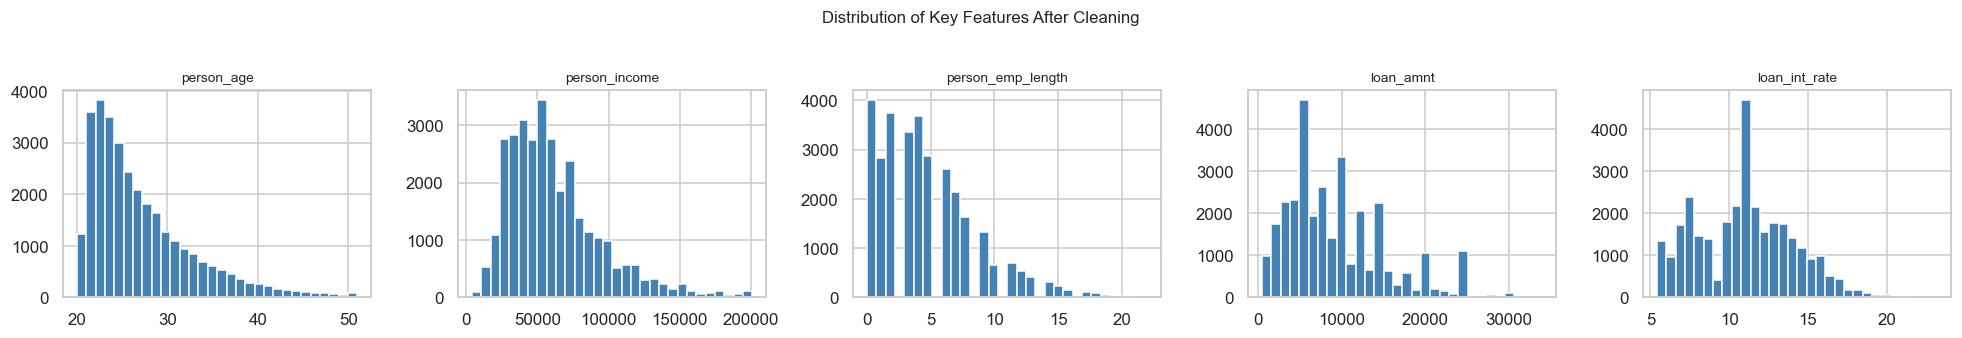

In [7]:
# ── 2.3  Remove Outliers (IQR method on key numeric features) ─────────────────
outlier_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate']

def remove_outliers_iqr(df, cols):
    mask = pd.Series([True] * len(df), index=df.index)
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= df[col].between(Q1 - 3 * IQR, Q3 + 3 * IQR)
    return df[mask]

before = len(df_credit)
df_credit = remove_outliers_iqr(df_credit, outlier_cols).reset_index(drop=True)
print(f'Rows before outlier removal: {before}  |  After: {len(df_credit)}  |  Removed: {before - len(df_credit)}')

# Visualise distributions post-cleaning
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 3))
for ax, col in zip(axes, outlier_cols):
    ax.hist(df_credit[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
plt.suptitle('Distribution of Key Features After Cleaning', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# ── 2.4  Build ESG Country Score ──────────────────────────────────────────────
# Select key sustainability indicators relevant to financial stability
esg_indicators = [
    'Renewable energy consumption (% of total final energy consumption)',
    'Access to electricity (% of population)',
    'Control of Corruption: Estimate',
    'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)',
    'GDP growth (annual %)',
    'Unemployment, total (% of total labor force) (national estimate)',
]

df_esg_filtered = df_esg_raw[df_esg_raw['Indicator name'].isin(esg_indicators)].copy()
# Use 2022 as the reference year (most recent with broad coverage)
df_esg_pivot = df_esg_filtered.pivot_table(
    index=['ISO3 code', 'Economy'],
    columns='Indicator name',
    values='2022'
).reset_index()

df_esg_pivot.columns.name = None
print(f'ESG country matrix — Shape: {df_esg_pivot.shape}')
df_esg_pivot.head()

ESG country matrix — Shape: (214, 5)


,ISO3 code,Economy,Access to electricity (% of population),Control of Corruption: Estimate,Renewable energy consumption (% of total final energy consumption)
0,ABW,Aruba,99.9,0.7565,8.8
1,AFG,Afghanistan,85.3,-1.1837,20.0
2,AGO,Angola,48.5,-0.6124,NaN
3,ALB,Albania,100.0,-0.4082,NaN
4,AND,Andorra,100.0,1.2703,18.7


---
## Stage 3 — Data Preparation
*Feature Scaling · Label Encoding · Feature Selection · Data Splitting*

In [9]:
# ── 3.1  Label Encoding — convert categorical → numeric ───────────────────────
df_model = df_credit.copy()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f'  Encoded: {col}')
print('\nAll categories encoded ✅')

  Encoded: person_home_ownership
  Encoded: loan_intent
  Encoded: loan_grade
  Encoded: cb_person_default_on_file

All categories encoded ✅


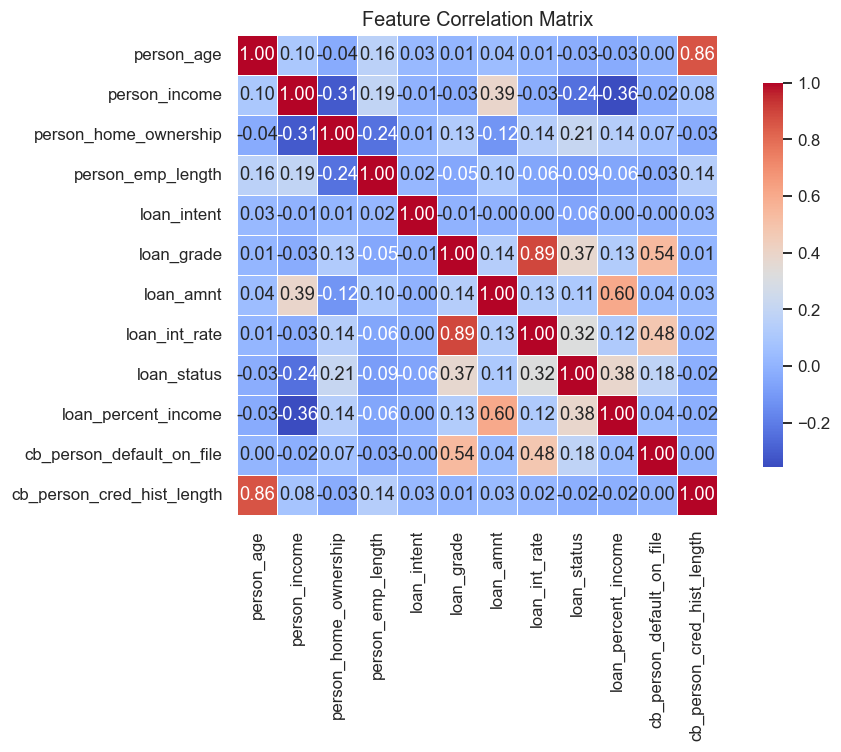


Selected features (9): ['person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file']


In [10]:
# ── 3.2  Feature Selection — Correlation heatmap ─────────────────────────────
plt.figure(figsize=(10, 7))
corr = df_model.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Drop low-variance / redundant features (threshold |corr with target| > 0.03)
target_corr = corr['loan_status'].abs().drop('loan_status')
selected_features = target_corr[target_corr > 0.03].index.tolist()
print(f'\nSelected features ({len(selected_features)}): {selected_features}')

In [11]:
# ── 3.3  Feature Scaling — Normalise numeric values ───────────────────────────
X = df_model[selected_features]
y = df_model['loan_status']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=selected_features)

print('Feature scaling summary:')
print(X_scaled.describe().round(2))

Feature scaling summary:
       person_income  person_home_ownership  person_emp_length  loan_intent  \
count       31565.00               31565.00           31565.00     31565.00   
mean           -0.00                  -0.00               0.00        -0.00   
std             1.00                   1.00               1.00         1.00   
min            -1.76                  -1.18              -1.22        -1.46   
25%            -0.72                  -1.18              -0.70        -0.88   
50%            -0.21                   0.91              -0.18         0.27   
75%             0.46                   0.91               0.60         0.85   
max             4.22                   0.91               4.49         1.43   

       loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
count    31565.00   31565.00       31565.00             31565.00   
mean         0.00       0.00           0.00                -0.00   
std          1.00       1.00           1.00                

In [12]:
# ── 3.4  Data Splitting — 80% Train / 20% Test ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test size  : {X_test.shape[0]:,} rows')
print(f'Default rate (train): {y_train.mean():.2%} | (test): {y_test.mean():.2%}')

Train size : 25,252 rows
Test size  : 6,313 rows
Default rate (train): 21.92% | (test): 21.92%


---
## Stage 4 — Train Model
*Train machine learning models against the training dataset*

In [13]:
# ── 4.1  Define candidate models ──────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Train all models
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✅  {name} trained')

✅  Logistic Regression trained
✅  Random Forest trained
✅  Gradient Boosting trained


In [14]:
# ── 4.2  Cross-Validation (5-fold AUC) ────────────────────────────────────────
print('5-Fold Cross-Validation — ROC-AUC Scores')
print('-' * 50)
cv_results = {}
for name, model in trained_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')

5-Fold Cross-Validation — ROC-AUC Scores
--------------------------------------------------
Logistic Regression       Mean: 0.8500  Std: 0.0036
Random Forest             Mean: 0.9311  Std: 0.0039
Gradient Boosting         Mean: 0.9257  Std: 0.0043


---
## Stage 5 — Evaluate Model
*Measure model performance using test and validation subsets*

In [15]:
# ── 5.1  Test-set evaluation ──────────────────────────────────────────────────
print('=== Test-Set Performance Report ===')
auc_scores = {}
for name, model in trained_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc
    print(f'\n── {name} (AUC = {auc:.4f}) ──')
    print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

=== Test-Set Performance Report ===

── Logistic Regression (AUC = 0.8518) ──
              precision    recall  f1-score   support

  No Default       0.86      0.95      0.91      4929
     Default       0.74      0.45      0.56      1384

    accuracy                           0.84      6313
   macro avg       0.80      0.70      0.73      6313
weighted avg       0.83      0.84      0.83      6313


── Random Forest (AUC = 0.9295) ──
              precision    recall  f1-score   support

  No Default       0.92      0.99      0.96      4929
     Default       0.96      0.71      0.81      1384

    accuracy                           0.93      6313
   macro avg       0.94      0.85      0.88      6313
weighted avg       0.93      0.93      0.92      6313


── Gradient Boosting (AUC = 0.9205) ──
              precision    recall  f1-score   support

  No Default       0.92      0.99      0.95      4929
     Default       0.93      0.68      0.79      1384

    accuracy                

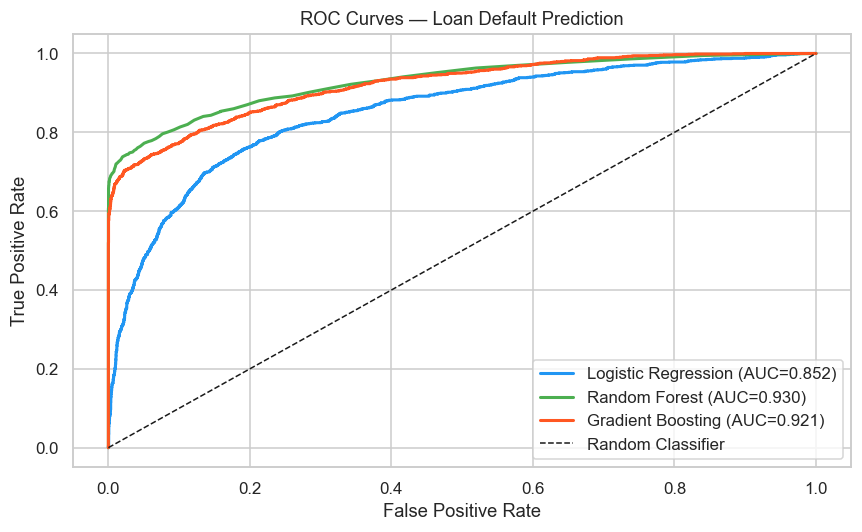

In [24]:
# ── 5.2  ROC Curves ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_scores[name]:.3f})', color=color, lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Loan Default Prediction', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model: Random Forest  (AUC = 0.9295)


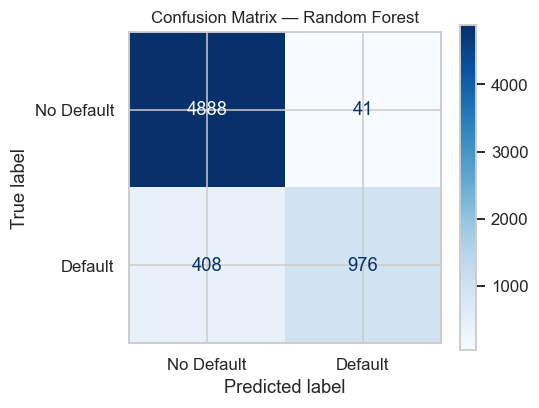

In [17]:
# ── 5.3  Confusion Matrix for best model ──────────────────────────────────────
best_name = max(auc_scores, key=auc_scores.get)
best_model = trained_models[best_name]
print(f'Best model: {best_name}  (AUC = {auc_scores[best_name]:.4f})')

y_pred_best = best_model.predict(X_test)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=11)
plt.tight_layout()
plt.show()

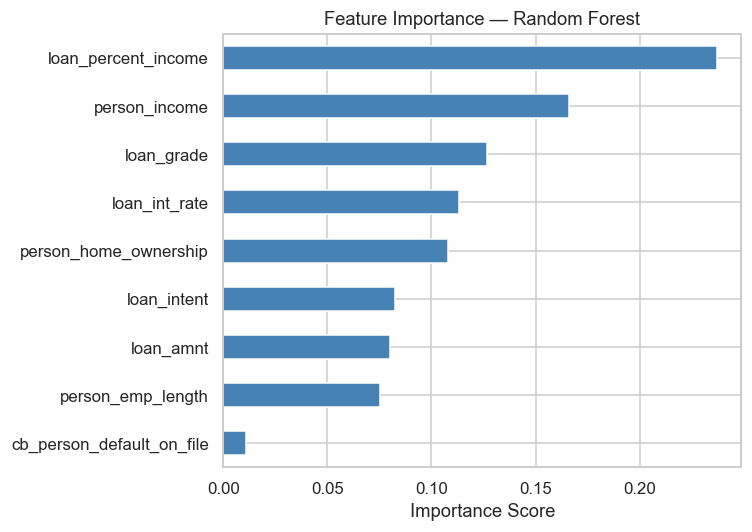

In [18]:
# ── 5.4  Feature Importance ───────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=selected_features)
else:
    importances = pd.Series(
        np.abs(best_model.coef_[0]), index=selected_features
    )

importances = importances.sort_values(ascending=True)
plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title(f'Feature Importance — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

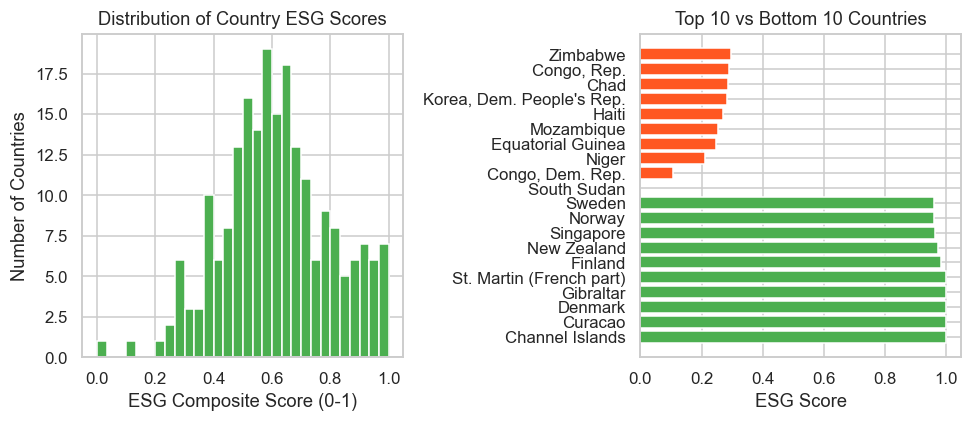


🌿 Top 10 Sustainable Economies:
                 Economy  ESG_Score
         Channel Islands   1.000000
                 Curacao   1.000000
                 Denmark   1.000000
               Gibraltar   1.000000
St. Martin (French part)   1.000000
                 Finland   0.981718
             New Zealand   0.971891
               Singapore   0.963848
                  Norway   0.960666
                  Sweden   0.959950


In [25]:
# ── 5.5  ESG Analysis — Sustainability vs Risk (Exploratory) ─────────────────
# Build a country ESG composite score and visualise distribution
esg_numeric = df_esg_pivot.select_dtypes(include='number')

# Normalise each indicator (0-1 min-max) then average for composite score
esg_norm = (esg_numeric - esg_numeric.min()) / (esg_numeric.max() - esg_numeric.min())

# Invert pollution column (lower = better)
pollution_col = [c for c in esg_norm.columns if 'PM2.5' in c]
if pollution_col:
    esg_norm[pollution_col[0]] = 1 - esg_norm[pollution_col[0]]

df_esg_pivot['ESG_Score'] = esg_norm.mean(axis=1)

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
df_esg_pivot['ESG_Score'].dropna().hist(bins=30, color='#4CAF50', edgecolor='white')
plt.xlabel('ESG Composite Score (0-1)')
plt.ylabel('Number of Countries')
plt.title('Distribution of Country ESG Scores')

plt.subplot(1, 2, 2)
top10 = df_esg_pivot.dropna(subset=['ESG_Score']).nlargest(10, 'ESG_Score')
bot10 = df_esg_pivot.dropna(subset=['ESG_Score']).nsmallest(10, 'ESG_Score')
combined = pd.concat([top10, bot10])
colors_bar = ['#4CAF50'] * 10 + ['#FF5722'] * 10
plt.barh(combined['Economy'], combined['ESG_Score'], color=colors_bar)
plt.xlabel('ESG Score')
plt.title('Top 10 vs Bottom 10 Countries')
plt.tight_layout()
plt.show()

print('\n🌿 Top 10 Sustainable Economies:')
print(top10[['Economy', 'ESG_Score']].to_string(index=False))

---
## Stage 6 — Performance Monitoring
*Continuously monitor model performance, retrain, and calibrate accordingly*

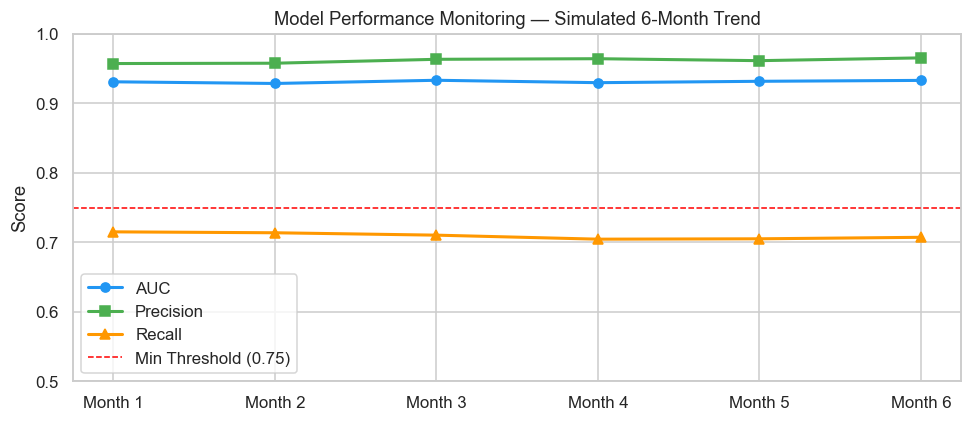


📋 Monitoring Summary:
  Avg AUC over 6 months   : 0.9311
  Avg Precision            : 0.9615
  Avg Recall               : 0.7094
  Retraining triggered?    : No


In [22]:
# ── 6.1  Simulated Performance Dashboard ──────────────────────────────────────
# In production this would track real-time predictions vs actual outcomes.
# Here we simulate monthly drift using random subsamples of the test set.
np.random.seed(0)
months = [f'Month {i}' for i in range(1, 7)]
auc_trend, precision_trend, recall_trend = [], [], []

from sklearn.metrics import precision_score, recall_score

for _ in months:
    idx = np.random.choice(len(X_test), size=int(len(X_test) * 0.7), replace=False)
    Xs, ys = X_test.iloc[idx], y_test.iloc[idx]
    yp = best_model.predict(Xs)
    ypr = best_model.predict_proba(Xs)[:, 1]
    auc_trend.append(roc_auc_score(ys, ypr))
    precision_trend.append(precision_score(ys, yp))
    recall_trend.append(recall_score(ys, yp))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(months, auc_trend,       marker='o', label='AUC',       color='#2196F3', lw=2)
ax.plot(months, precision_trend, marker='s', label='Precision',  color='#4CAF50', lw=2)
ax.plot(months, recall_trend,    marker='^', label='Recall',     color='#FF9800', lw=2)
ax.axhline(0.75, color='red', linestyle='--', lw=1, label='Min Threshold (0.75)')
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Performance Monitoring — Simulated 6-Month Trend', fontsize=12)
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

print('\n📋 Monitoring Summary:')
print(f'  Avg AUC over 6 months   : {np.mean(auc_trend):.4f}')
print(f'  Avg Precision            : {np.mean(precision_trend):.4f}')
print(f'  Avg Recall               : {np.mean(recall_trend):.4f}')
flag = any(a < 0.75 for a in auc_trend)
print(f'  Retraining triggered?    : {"YES — AUC dropped below threshold" if flag else "No"}')

In [23]:
# ── 6.2  Final Project Summary ────────────────────────────────────────────────
print('=' * 60)
print('  AI-BASED FINANCIAL RISK ANALYSIS — PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset size (after cleaning) : {len(df_credit):,} records')
print(f'  Features selected             : {len(selected_features)}')
print(f'  Best model                    : {best_name}')
print(f'  Best AUC (test set)           : {auc_scores[best_name]:.4f}')
print(f'  ESG countries indexed         : {df_esg_pivot["ESG_Score"].notna().sum()}')
print()
print('  Business Value:')
print('  ✅  Reduces default losses by identifying high-risk loans early')
print('  ✅  ESG integration steers capital toward sustainable economies')
print('  ✅  Monitoring loop ensures model stays calibrated over time')
print('=' * 60)

  AI-BASED FINANCIAL RISK ANALYSIS — PROJECT SUMMARY
  Dataset size (after cleaning) : 31,565 records
  Features selected             : 9
  Best model                    : Random Forest
  Best AUC (test set)           : 0.9295
  ESG countries indexed         : 214

  Business Value:
  ✅  Reduces default losses by identifying high-risk loans early
  ✅  ESG integration steers capital toward sustainable economies
  ✅  Monitoring loop ensures model stays calibrated over time
